# Prediction quality against the historical baseline, seed-matched

`part_4` shows every condition's own distribution over repetitions. This notebook asks
the sharper question directly: is a condition's difference from `historical_bce` bigger
than the noise between repetitions, or does it just look that way in a raw mean
comparison? It is the one place in this campaign that pairs on realized seed rather than
comparing unpaired distributions.

## Introduction

A distribution over seeds answers "how good is each condition"; the paired difference
against the historical baseline, matched on realized seed and on the data/backbone/
training contracts, answers "how much did changing the objective move this metric" with
far less variance, because the seed is held fixed on both sides. A condition whose
interval excludes zero is distinguished from the baseline on this campaign; one whose
interval spans zero is not, however large its raw mean gap looks.

### Assumptions

- **`historical_bce` is a genuinely separate run, not part of this repetition-indexed
  grid** (see `part_0_0`). Pairing therefore only succeeds where the baseline's own
  realized seeds and contracts happen to match a `predictive_initial` condition's; with
  a single baseline run this means at most one matched pair per condition, not five —
  `paired_comparisons` reports `pairs=0` with an explicit reason where no match exists,
  rather than silently comparing unmatched runs.
- **No multiple-comparison correction is applied.** With 8 swept conditions against one
  baseline, a single near-boundary interval is weak evidence; the pattern across a loss
  family is what should be read, exactly as `part_4`'s own contrast section states.
- **The primary comparison is validation-split, `train_supported` scope,
  `annotation_retrieval` population, `average_precision`** — the same cell `part_4`'s own
  summary table highlights, so the two notebooks describe the same quantity from two
  angles (distribution vs. paired contrast) rather than two different ones.

### Notation

For condition $c$ paired against the baseline $b$ on matched seed $r$,
$\delta_c(r) = \mathrm{AP}_c(r) - \mathrm{AP}_b(r)$. The reported interval is the
descriptive 95% Student-t interval of $\delta_c$ across its matched pairs.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_precompute as cache
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_reports as reports
from msi_autoencoder_wrapper.utils.logger import get_custom_logger
from msi_autoencoder_wrapper.visualization import resolve_theme

logger = get_custom_logger("prediction_global_vs_baseline")

2026-09-16 21:03:09,657 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-16 21:03:09,660 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-09-16 21:03:10,282 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-16 21:03:10,284 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 28 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-16 21:03:10,286 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-16 21:03:10,288 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 35 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


## Configuration

## Producing the tables this notebook reads

### Methodology

#### Implementation

No new precompute routine backs this notebook: `prediction` is already written by the
base full-campaign inference cache. This notebook only derives the paired-seed contrast
from it, a cheap operation shared with `part_4`'s own baseline-contrast section
(`predictive_reports.experimental_units`/`paired_comparisons`/`baseline_contrasts`).

If the base table is missing, `predictive_precompute.load_table` names the base
precompute command that produces it.

### Remarks

### Notes

In [ ]:
SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/16_09_26_metaspace_heads_vpu/analysis_settings.yaml")
NOTEBOOK_DIR = SETTINGS_PATH.parent
RESULTS = NOTEBOOK_DIR / "part_5_prediction_global_vs_baseline_results"
RESULTS.mkdir(exist_ok=True)

settings = campaign.load_settings(SETTINGS_PATH)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import (
    load_model_catalog, load_visualization_theme, select_catalog_frame,
)
models = load_model_catalog(settings)

prediction = select_catalog_frame(cache.load_table(settings, "prediction"), models)
KEYS = ["split", "population", "scope", "metric"]
units = reports.experimental_units(prediction, models, KEYS)
CONDITION_ORDER = reports.condition_order(models)

theme = load_visualization_theme(settings)
theme.apply()
LABEL_COLOR = {label: theme.color_for_model(label, index) for index, label in enumerate(CONDITION_ORDER)}

# --- embedded figure resolution --------------------------------------------
FIGURE_RASTER_DPI = 100
plt.rcParams["savefig.dpi"] = FIGURE_RASTER_DPI
# ---------------------------------------------------------------------------

print(f"{models.model_id.nunique()} ready model(s), {len(units)} experimental unit(s)")

## Is the between-condition difference bigger than seed noise?

### Methodology

#### Theoretical

A distribution over seeds answers "how good is each condition"; the paired difference
against the historical baseline, matched on realized seed and on the data/backbone/
training contracts, answers "how much did changing the objective move this metric" with
far less variance, because the seed is held fixed on both sides. A condition whose
interval excludes zero is distinguished from the baseline on this campaign; one whose
interval spans zero is not, however large its raw mean gap looks.

#### Implementation

`paired_comparisons` matches conditions on realized seeds and all three contracts
inside each (split, population, scope, metric) cell; `baseline_contrasts` restricts the
result to comparisons against the source whose role is `baseline` and rewrites every
row so the reported value is candidate minus baseline. Intervals are exploratory
Student-t intervals across the matched seeds and are not corrected for the number of
conditions examined.

#### Figure descriptions

One row per condition, ordered as in the campaign's condition order; the marker is the
mean paired difference in validation macro average precision against the historical
baseline, and the horizontal segment is the across-seed interval. The dashed vertical
line at zero is no effect. The tick label gives the number of matched pairs.

### Remarks

### Notes

2026-09-16 21:03:17,883 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:194 | Oriented 374 baseline contrasts as candidate minus reference.


,label,pairs,mean_difference,ci_low,ci_high
143,bce_global_positive_penalty (PositiveWeightedM...,5,0.0016,-0.0038,0.0069
329,bce_per_class_positive_penalty (PositiveWeight...,5,0.0046,-0.0034,0.0125


2026-09-16 21:03:18,133 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:336 | Saved 2 analytical tables in assets/experiments/autoencoder_architecture/notebooks/segmentation_model/16_09_26_metaspace_heads_vpu/part_5_prediction_global_vs_baseline_results.


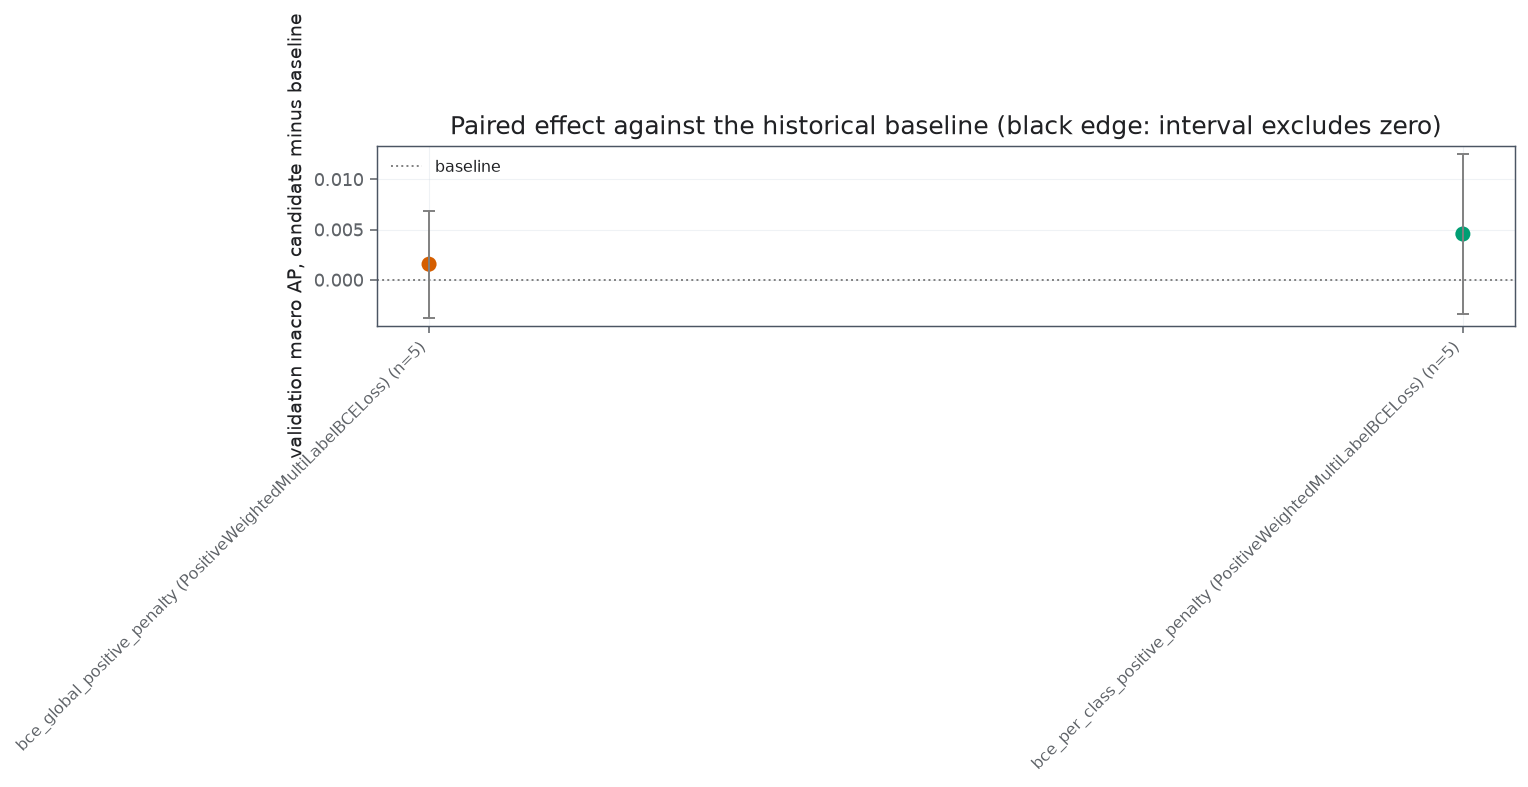

In [3]:
differences, contrasts = reports.paired_comparisons(units, KEYS)
oriented = reports.baseline_contrasts(contrasts, models)
selected = oriented.query("split == 'validation' and scope == 'train_supported' and "
                          "population == 'annotation_retrieval' and metric == 'average_precision'")
order_index = {label: position for position, label in enumerate(CONDITION_ORDER)}
selected = selected.assign(_order=selected.label.map(order_index)).sort_values("_order").drop(columns="_order")

plotted = selected.dropna(subset=["mean_difference"])
positions = np.arange(len(plotted))
figure, axis = plt.subplots(figsize=(11.0, 5.0), dpi=theme.figure_dpi)
axis.errorbar(
    positions, plotted["mean_difference"],
    yerr=[plotted["mean_difference"] - plotted["ci_low"], plotted["ci_high"] - plotted["mean_difference"]],
    fmt="none", ecolor="grey", elinewidth=1, capsize=3,
)
axis.scatter(
    positions, plotted["mean_difference"], s=60,
    color=[LABEL_COLOR[label] for label in plotted["label"]],
    edgecolor=["black" if (ci_low > 0 or ci_high < 0) else "none"
               for ci_low, ci_high in zip(plotted["ci_low"], plotted["ci_high"])], linewidth=1.2,
)
axis.axhline(0.0, color="grey", linestyle=":", linewidth=1, label="baseline")
axis.set_xticks(positions)
axis.set_xticklabels([f"{label} (n={int(pairs)})" for label, pairs in zip(plotted["label"], plotted["pairs"])],
                     rotation=45, ha="right", fontsize=8)
axis.set(ylabel="validation macro AP, candidate minus baseline",
        title="Paired effect against the historical baseline (black edge: interval excludes zero)")
axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
axis.legend(fontsize=8, frameon=theme.legend_frame)
figure.tight_layout()
figure.savefig(RESULTS / "baseline_contrasts.png")

display(selected[["label", "pairs", "mean_difference", "ci_low", "ci_high"]].round(4))
reports.save_tables(RESULTS, paired_differences=differences, baseline_contrasts=oriented)

## Reproducible artifacts

### Methodology

#### Implementation

The measured `prediction` table and its provenance are written by the base precompute
runner, not here; this notebook adds only the paired-difference and baseline-contrast
tables it derives from it, plus the figure above.

The results directory is deliberately not versioned: it is regenerable.

### Remarks

### Notes

In [4]:
print("derived tables/figures written:", sorted(path.name for path in RESULTS.glob("*")))

derived tables/figures written: ['baseline_contrasts.csv', 'baseline_contrasts.png', 'paired_differences.csv']


## Results / Summary

### LLM

Not yet run against the real campaign cache. This notebook has not been executed
against `data/kidney_workspace`; run the base inference cache, then write this section
from the actually observed paired contrasts before treating any interpretation here as
verified. (The predecessor notebook this was ported from did complete a real run on
2026-09-13 against the same underlying campaign and found `pu_ranking` and the
`pn_bce_*` family significantly below baseline on this exact metric — worth checking
against once this notebook is re-run, but not restated here as already-verified for
this notebook's own structure.)

### Person